In [1]:
# --- Tutorial setup ---
# This cell loads everything needed to run this notebook standalone.
# It is hidden in the rendered documentation but visible when running the
# notebook as a tutorial.
import os
import sys
sys.path.insert(0, "/".join(["..", "python"]))

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle, FancyArrowPatch
import numpy as np
import scipy.ndimage
from gridr.core.convolution.fft_filtering import fft_array_filter
from notebook_utils import plot_im, mpl_plot_wrapper
IN_DOC_BUILD = os.environ.get("DOC_BUILD", "0") == "1"
import notebook_utils
notebook_utils.FORCE_MPL_INTERACTIVE = True
if not IN_DOC_BUILD and not notebook_utils.FORCE_MPL_INTERACTIVE:
    from bokeh.io import output_notebook  # enables plot interface in J notebook
    output_notebook()


@mpl_plot_wrapper
def plot_mesh3d_static(x, y, data, *, height=350, width=350, prefix=None):
    """Plot a 2D array as a 3D wireframe surface."""
    fig = plt.figure(figsize=(width / 100, height / 100), dpi=100)
    ax = fig.add_subplot(111, projection="3d")
    X, Y = np.meshgrid(x, y)
    ax.plot_wireframe(X, Y, data, rstride=1, cstride=1, color="blue", linewidth=0.3)
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    return fig


def gaussian_kernel_2d(shape, sigma):
    """
    Generates a normalized 2D Gaussian kernel.

    :param shape: Kernel size (int for a square kernel, or tuple (height, width))
    :param sigma: Standard deviation of the Gaussian (float or tuple (sigma_y, sigma_x))
    :return: a tuple containing :
        - 1D Numpy array representing x coordinates
        - 1D Numpy array representing y coordinates
        - 2D NumPy array representing the kernel
    """
    # Handle scalar or tuple inputs for shape and sigma
    if isinstance(shape, int):
        h = w = shape
    else:
        h, w = shape

    if isinstance(sigma, (int, float)):
        sigma_y = sigma_x = sigma
    else:
        sigma_y, sigma_x = sigma

    # Create centered coordinates (e.g., size 5 -> [-2, -1, 0, 1, 2])
    y = np.arange(-(h // 2), h // 2 + 1 if h % 2 != 0 else h // 2)
    x = np.arange(-(w // 2), w // 2 + 1 if w % 2 != 0 else w // 2)

    # 2D Grid
    x_grid, y_grid = np.meshgrid(x, y)

    # Calculate 2D Gaussian function
    kernel = np.exp(-0.5 * ((x_grid / sigma_x) ** 2 + (y_grid / sigma_y) ** 2))

    # Normalize so the sum of all elements equals 1
    kernel_sum = np.sum(kernel)
    if kernel_sum != 0:
        kernel /= kernel_sum

    return x, y, kernel


def generate_high_frequency_test_image(size=512, frequency_factor=150):
    """
    Generates a 2D zone plate (chirp) image containing high spatial frequencies.

    :param size: Image resolution (size x size)
    :param frequency_factor: Controls how rapidly the frequency increases towards the edges
    :return: 2D NumPy array representing the test image
    """
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    X, Y = np.meshgrid(x, y)

    # Frequency increases proportionally to the squared distance from the center
    R2 = X ** 2 + Y ** 2
    return 0.5 + 0.5 * np.sin(frequency_factor * R2)


def _add_image_axes(fig, img, left, bottom, fig_w, fig_h, scale, **imshow_kw):
    """Add an axes displaying img at native resolution, positioned in screen pixels."""
    h, w = img.shape[:2]
    ax = fig.add_axes([left / fig_w, bottom / fig_h,
                       w * scale / fig_w, h * scale / fig_h])
    ax.imshow(img, cmap="gray", interpolation="none", resample=False,
              aspect="equal", **imshow_kw)
    # imshow puts pixel centers on integers, so pixel edges sit at +/- 0.5
    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(h - 0.5, -0.5)
    ax.set_axis_off()
    return ax


def _infer_factor(image_filtered, image_decimated):
    """Infer the integer decimation factor from the shapes of both images."""
    f = np.round(np.asarray(image_filtered.shape[:2])
                 / np.asarray(image_decimated.shape[:2])).astype(int)
    return tuple(f)


@mpl_plot_wrapper
def plot_image_decimation(image_input, image_filtered, image_decimated,
                          factor=None, offset=0, prefix=None, scale=1, dpi=100,
                          match_footprint=True, show_samples=None):
    """Plot the input, filtered and decimated images side by side.

    Each image pixel is rendered as an integer number of screen pixels, with no
    interpolation. When match_footprint is True, the decimated image is rendered
    at scale x factor so that it covers the same extent as the filtered one;
    otherwise every panel uses the same scale and the decimated image appears
    smaller. Panels are vertically centered on each other and linked by arrows.

    The decimation grid is assumed to be image_filtered[offset::factor].
    """
    if factor is None:
        factor = _infer_factor(image_filtered, image_decimated)
    fy, fx = (factor, factor) if np.isscalar(factor) else factor
    oy, ox = (offset, offset) if np.isscalar(offset) else offset

    # Per-panel scale, in screen pixels per image pixel
    dec_scale = (scale * max(fy, fx)) if match_footprint else scale
    names = ["input", "filtered", "decimated"]
    panels = [(image_input, scale),
              (image_filtered, scale),
              (image_decimated, dec_scale)]
    arrow_labels = ["filter", f"1/{fy}" if fy == fx else f"1/{fy}, 1/{fx}"]

    # Layout in screen pixels (integers to stay on the pixel grid)
    m_left, m_right, m_top, m_bottom = 10, 10, 24, 30
    gap = 50  # horizontal room for the arrows
    widths = [img.shape[1] * s for img, s in panels]
    heights = [img.shape[0] * s for img, s in panels]
    ax_h = max(heights)
    fig_w = m_left + sum(widths) + gap * (len(panels) - 1) + m_right
    fig_h = ax_h + m_top + m_bottom

    fig = plt.figure(figsize=(fig_w / dpi, fig_h / dpi), dpi=dpi)
    norm_kw = dict(vmin=np.nanmin(image_input), vmax=np.nanmax(image_input))

    left = m_left
    y_center = m_bottom + ax_h / 2
    for i, (img, s) in enumerate(panels):
        bottom = m_bottom + (ax_h - heights[i]) // 2
        ax = _add_image_axes(fig, img, left, bottom, fig_w, fig_h, s, **norm_kw)

        # Sampling grid overlaid on the filtered image
        if i == 1:
            ph, pw = img.shape[:2]
            rows = np.arange(oy, ph, fy)
            cols = np.arange(ox, pw, fx)
            draw = show_samples
            if draw is None:
                draw = rows.size * cols.size <= 2500
            if draw:
                cc, rr = np.meshgrid(cols, rows)
                ax.plot(cc.ravel(), rr.ravel(), linestyle="none", marker="s",
                        markersize=1.5, color="magenta")

        if i > 0:
            x0, x1 = left - gap + 6, left - 6
            fig.add_artist(FancyArrowPatch(
                (x0 / fig_w, y_center / fig_h), (x1 / fig_w, y_center / fig_h),
                transform=fig.transFigure, arrowstyle="-|>",
                mutation_scale=10, linewidth=1, color="0.3"))
            fig.text((x0 + x1) / 2 / fig_w, (y_center + 8) / fig_h,
                     arrow_labels[i - 1], ha="center", va="bottom", fontsize=7,
                     color="0.3")

        left += widths[i] + gap

    shapes = " - ".join(f"{n} ({img.shape[0]}x{img.shape[1]})"
                        for (img, _), n in zip(panels, names))
    fig.text(0.5, 1 - 4 / fig_h, shapes, ha="center", va="top", fontsize=8)
    return fig


@mpl_plot_wrapper
def plot_decimation_phase_2d(n=12, q=4, dpi=100, prefix=None):
    """Illustrate the leading and centered decimation phases on a 2D pixel grid."""
    ny, nx = (n, n) if np.isscalar(n) else n
    qy, qx = (q, q) if np.isscalar(q) else q
    modes = [("leading", (0, 0), "tab:blue"),
             ("centered", ((qy - 1) // 2, (qx - 1) // 2), "tab:green")]

    fig, axes = plt.subplots(1, len(modes), figsize=(7 * 0.7, 3.8 * 0.7), dpi=dpi)
    for ax, (name, (oy, ox), color) in zip(axes, modes):
        # Full resolution pixels
        for i in range(ny):
            for j in range(nx):
                ax.add_patch(Rectangle((j, i), 1, 1, facecolor="0.94",
                                       edgecolor="0.75", linewidth=0.5))
        # Q x Q blocks
        for by in range(0, ny, qy):
            for bx in range(0, nx, qx):
                ax.add_patch(Rectangle((bx, by), min(qx, nx - bx), min(qy, ny - by),
                                       fill=False, edgecolor="0.25", linewidth=1.4))
        # True block centers
        cy = np.arange(0, ny, qy) + qy / 2
        cx = np.arange(0, nx, qx) + qx / 2
        gx, gy = np.meshgrid(cx, cy)
        ax.plot(gx.ravel(), gy.ravel(), linestyle="none", marker="+",
                markersize=8, color="tab:red", markeredgewidth=1.2, zorder=4)
        # Kept samples (center of the retained full resolution pixel)
        ky = np.arange(oy, ny, qy) + 0.5
        kx = np.arange(ox, nx, qx) + 0.5
        sx, sy = np.meshgrid(kx, ky)
        ax.plot(sx.ravel(), sy.ravel(), linestyle="none", marker="s",
                markersize=7, markerfacecolor=color, markeredgecolor="white",
                markeredgewidth=0.8, zorder=3)

        ax.set_title(f'decimation="{name}"', fontsize=9)
        ax.set_xlim(0, nx)
        ax.set_ylim(ny, 0)  # image convention: rows downwards
        ax.set_aspect("equal")
        ax.set_xticks(np.arange(0, nx + 1, qx))
        ax.set_yticks(np.arange(0, ny + 1, qy))
        ax.tick_params(labelsize=7)

    fig.suptitle(f"Decimation phase (Q = {qy}x{qx})", fontsize=10)
    fig.text(0.5, 0.02, "squares: kept samples    +: true block center",
             ha="center", fontsize=8, color="0.3")
    fig.tight_layout(rect=[0, 0.06, 1, 0.94])
    return fig


def _kernel_response(kernel, shape):
    """Frequency response of the kernel, evaluated on the image grid."""
    kpad = np.zeros(shape, dtype=float)
    kh, kw = kernel.shape
    kpad[:kh, :kw] = kernel
    kpad = np.roll(kpad, (-(kh // 2), -(kw // 2)), axis=(0, 1))
    return np.abs(np.fft.fftshift(np.fft.fft2(kpad)))


def _zoom_ticks(zooms):
    """Ticks placed at the Nyquist limit (0.5 / Q) of each decimation factor."""
    pos, lab = [0.0], ["0"]
    for z in sorted(set(zooms)):
        f = 0.5 / z
        pos += [f, -f]
        lab += [f"${2 * z}^{{-1}}$", f"$-{2 * z}^{{-1}}$"]
    return pos, lab


@mpl_plot_wrapper
def plot_spectra(image, kernel, zooms=(4, 6), prefix=None, dpi=100, vmin=1e-5,
                 levels=(0.5, 0.1, 0.01), freq_max=0.25, panel_size=3.6):
    """Show the 2D spectra of the image, the kernel and the filtered image.
 
    The three panels are laid out on a 2 x 2 grid: the image spectrum and the
    filter response on the first row, their product on the second row. The
    remaining cell carries the legend.
 
    Each dashed square marks the band kept by a decimation of the corresponding
    factor (+/- 0.5 / Q in normalized frequency). Energy left outside a square in
    the filtered spectrum is the one that folds back for that decimation factor.
 
    The image and filtered spectra use a logarithmic scale to cover their dynamic
    range, while the filter response uses a linear scale with contour lines at the
    given attenuation levels, which is easier to read to decide where it becomes
    negligible.
    """
    if np.isscalar(zooms):
        zooms = (zooms,)
 
    spec_img = np.abs(np.fft.fftshift(np.fft.fft2(image)))
    spec_img /= spec_img.max()
    spec_flt = _kernel_response(kernel, image.shape[:2])
    spec_flt /= spec_flt.max()
    spec_out = spec_img * spec_flt
 
    h, w = image.shape[:2]
    fy = np.fft.fftshift(np.fft.fftfreq(h))
    fx = np.fft.fftshift(np.fft.fftfreq(w))
    extent = [fx[0], -fx[0], -fy[0], fy[0]]  # normalized frequency, cycles/pixel
    colors = ["tab:green", "tab:orange", "tab:red", "tab:purple"]
    pos, lab = _zoom_ticks(zooms)
 
    fig, axes = plt.subplots(2, 2, figsize=(2 * panel_size, 2 * panel_size), dpi=dpi)
    axes = axes.ravel()
    norm = LogNorm(vmin=vmin, vmax=1.0)
 
    # Image spectrum and filtered spectrum: log scale
    for ax, (name, data) in zip((axes[0], axes[2]),
                                [("image spectrum", spec_img),
                                 ("filtered spectrum", spec_out)]):
        im = ax.imshow(np.maximum(data, vmin), norm=norm, extent=extent,
                       cmap="viridis", interpolation="nearest")
        ax.set_title(name, fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(labelsize=7)
 
    # Filter response: linear scale with attenuation contours
    ax = axes[1]
    im = ax.imshow(spec_flt, vmin=0, vmax=1, extent=extent,
                   cmap="viridis", interpolation="nearest")
    cs = ax.contour(fx, fy, spec_flt, levels=sorted(levels), colors="white",
                    linewidths=0.8)
    ax.clabel(cs, fmt=lambda v: f"{v:.0%}", fontsize=9, inline=True)
    ax.set_title("filter response", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(labelsize=7)
 
    # Decimation squares and axes, common to the three spectra
    handles = []
    for k, ax in enumerate(axes[:3]):
        for z, color in zip(zooms, colors):
            limit = 0.5 / z
            rect = Rectangle((-limit, -limit), 2 * limit, 2 * limit, fill=False,
                             edgecolor=color, linestyle="--", linewidth=1.3,
                             label=f"$Q$ = {z}")
            ax.add_patch(rect)
            if k == 0:
                handles.append(rect)
        ax.set_xticks(pos)
        ax.set_xticklabels(lab, fontsize=7, rotation=45, ha="right")
        ax.set_yticks(pos)
        ax.set_yticklabels(lab, fontsize=7)
        ax.set_xlabel("$f_x$ (cycles/pixel)", fontsize=9)
        ax.set_ylabel("$f_y$ (cycles/pixel)", fontsize=9)
        ax.set_xlim(-freq_max, freq_max)
        ax.set_ylim(freq_max, -freq_max)  # same orientation as extent
        ax.set_aspect("equal")
 
    # Fourth cell: legend only
    axes[3].set_axis_off()
    axes[3].legend(handles=handles, loc="center", frameon=False, fontsize=10,
                   title="Band kept by the decimation", title_fontsize=10)
 
    fig.suptitle(f"2D spectra, displayed over "
                 f"$[-{freq_max:.3g}, {freq_max:.3g}]$ cycles/pixel", fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    return fig



# The `gaussian_kernel_2d` function implements the formula given in the first tutorial.
gaussian_sigma = 4.
x, y, kernel = gaussian_kernel_2d(shape=int(gaussian_sigma * 6 + 1), sigma=gaussian_sigma)

# Zooming out and aliasing

This fourth tutorial describes how to resample the filtered output, and the restrictions
that currently apply to the zoom factor.

**What you'll learn**

- How to apply a zoom factor through the ``zoom`` argument
- Why only zooming out is currently available
- How to control the phase of the decimation
- How aliasing shows up when decimating, and how to check a kernel against a decimation factor
- Which limitations come from the SciPy backends, and what is planned to lift them

`fft_array_filter` accepts a `zoom` parameter that resamples the output, given either as
an integer or as a rational number $P / Q$.

GridR does not currently implement zooming in the Fourier domain, so only zooming out is
available: the ratio must reduce to $1 / Q$. An integer zoom is therefore restricted to 1,
and a rational zoom $P / Q$ is rejected as soon as $P / gcd(P, Q)$ is greater than 1.

The two directions are not symmetric. Zooming out only keeps a subset of the samples the
convolution already produces, which can be done on the filtered image. Zooming in creates
samples lying between the existing ones, which in the Fourier domain means padding the
spectrum with zeros before the inverse transform. The SciPy backends give no access to
that intermediate spectrum, so this cannot be built on top of them. Under these
restrictions, zooming out amounts to a decimation of the convolution result.

## A test pattern for aliasing

For this section we replace the mandrill image with a synthetic test pattern. It is a
zone plate: a sine wave whose frequency increases with the distance from the center, so
a single image covers a wide range of spatial frequencies. Aliasing is far easier to
observe on such a pattern than on a natural image.

In [2]:
hf_arr = generate_high_frequency_test_image(size=192, frequency_factor=60)

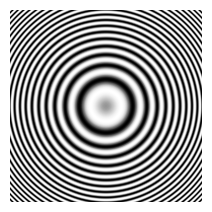

In [3]:
plot_im(hf_arr, prefix="004_hf_image")

## Decimation

With the ratio reduced to $1 / Q$, the output keeps one pixel out of $Q$ along each axis.
Using the `zoom` parameter to decimate is equivalent to applying a strided slice to the
undecimated output. This is exactly what GridR currently does internally: the image is
filtered at full resolution, and the filtered image is then decimated.

```{note}
This is a limitation of the SciPy backends, which always compute the convolution at full
resolution. Samples that are discarded by the decimation are therefore computed anyway,
and unlike the extra margins discussed previously, this overhead grows with the decimation
factor. In the Fourier domain, the decimation could be applied to the filtered spectrum
before the inverse transform, which would then only be computed at the output resolution.
This requires an access to the intermediate spectrum that the SciPy functions do not
provide, as they perform the whole convolution in a single call.
```

In [4]:
# Decimation with a factor 6
filtered_result_decimated_same = fft_array_filter(
        arr=hf_arr,
        kernel=kernel,
        win=None,
        boundary="reflect",
        out_mode="same",
        zoom=(1, 6),
        decimation="leading",
        axes=None,
        dtype=None,
        method="overlap_add",
    )

In [5]:
# Same call without decimation
filtered_result_same = fft_array_filter(
        arr=hf_arr,
        kernel=kernel,
        win=None,
        boundary="reflect",
        out_mode="same",
        zoom=(1, 1),
        decimation="leading",
        axes=None,
        dtype=None,
        method="overlap_add",
    )

Both results can be compared directly:

In [6]:
np.testing.assert_equal(filtered_result_decimated_same.data,
                        filtered_result_same.data[::6, ::6])

The figure below shows the three stages: the input image, the filtered image with the
decimation grid overlaid, and the decimated output.

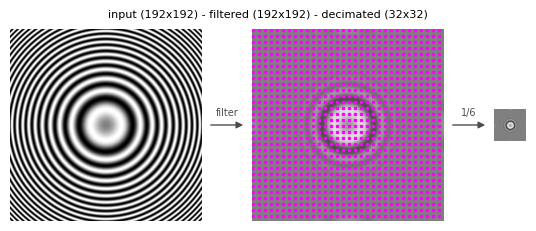

In [7]:
_ = plot_image_decimation(hf_arr, filtered_result_same.data,
                          filtered_result_decimated_same.data,
                          match_footprint=False, show_samples=True,
                          prefix="004_decimate_6_process")

### Decimation phase

Keeping one pixel out of $Q$ leaves the choice of which one. This choice sets the position
of the output grid relative to the input grid, and therefore the geometric footprint of
the output image. The `decimation` parameter controls it. Two modes are currently
available.

In `"leading"` mode, the decimation starts at the first pixel of the output. This
position depends on the selected output mode, so the grid is not necessarily aligned
with the first pixel of the production window when `out_mode` is not `"same"`.

In `"centered"` mode, the grid is aligned with the center of each $Q \times Q$ block of
full resolution pixels, where $Q$ is the decimation factor. The first block has its upper
left corner aligned with the upper left corner of the full resolution output image. The
shift is applied after the filtering, through slicing, and is therefore limited to an
integer number of pixels. It is computed as $\lfloor (Q - 1) / 2 \rfloor$, which gives the exact center
for an odd decimation factor, and a bias of half a full resolution pixel towards the upper
left for an even factor.

The two figures below compare both modes, first for an even factor and then for an odd
one. With $Q = 5$ the kept sample falls exactly on the block center, while with $Q = 4$ it
sits half a pixel towards the upper left.

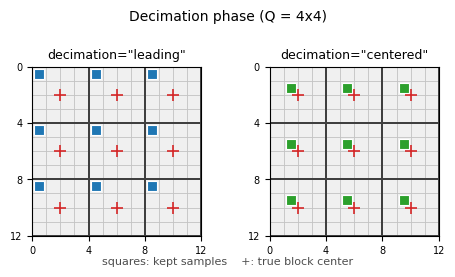

In [8]:
_ = plot_decimation_phase_2d(n=12, q=4, dpi=100, prefix="004_decimation_phase_4")

In [ ]:
_ = plot_decimation_phase_2d(n=12, q=5, dpi=100, prefix="004_decimation_phase_5")

The shift can be checked on a real call. With $Q = 6$ the offset is
$\lfloor (6 - 1) / 2 \rfloor = 2$, so the centered result is the undecimated output sampled from index 2
instead of index 0.

In [ ]:
# Decimation with a factor 6, centered phase
filtered_result_decimated_same_centered = fft_array_filter(
        arr=hf_arr,
        kernel=kernel,
        win=None,
        boundary="reflect",
        out_mode="same",
        zoom=(1, 6),
        decimation="centered",
        axes=None,
        dtype=None,
        method="overlap_add",
    )

np.testing.assert_equal(filtered_result_decimated_same_centered.data,
                        filtered_result_same.data[2::6, 2::6])

```{note}
The half pixel bias for even decimation factors comes from the same limitation. In the
Fourier domain, a sub-pixel shift is a simple phase ramp applied to the filtered spectrum,
which would place the samples exactly at the center of each block. Here again, this
requires an access to the intermediate spectrum that the SciPy functions do not provide,
so the shift can only be applied afterwards, by slicing, and is therefore limited to an
integer number of pixels.
```

## Aliasing

```{warning}
Decimation lowers the sampling rate of the output, and any content above the new Nyquist
frequency is folded back into the image. Nothing in `fft_array_filter` prevents this: the
kernel is the only anti-aliasing filter in the chain, and choosing a cutoff matched to
the decimation factor is the caller's responsibility.
```

The decimation applied above used a factor of 6. The small size of the decimated image
makes the artifacts hard to see, so it is displayed below at a larger scale.

In [ ]:
# decimated valid slice to ignore edge effects - computed from Q applied to half kernel margin
valid_slice_6 = (
    slice(kernel.shape[0]//2//6, -kernel.shape[0]//2//6),
    slice(kernel.shape[1]//2//6, -kernel.shape[1]//2//6),
)
plot_im(scipy.ndimage.zoom(filtered_result_decimated_same.data[valid_slice_6], 6, order=3),
        prefix="004_aliasing_decimate_6")

The rings appearing in the outer part of the pattern, where the local frequency is
highest, are not present in the input image: they are the frequencies folded back below
the new Nyquist frequency. Where they come from is easier to see on the kernel and its
frequency response.

As a reminder, the kernel used here is a Gaussian with $\sigma = 4$ on a $25 \times 25$ support.

In [ ]:
_ = plot_mesh3d_static(x, y, kernel, prefix="004_gaussian_kernel_sigma4")

```{note}
A Gaussian is not a good anti-aliasing filter. Its frequency response decreases slowly, so
reaching a given attenuation at the new Nyquist frequency requires a large standard
deviation, and therefore blurs the image more than necessary. Filters with a sharper
transition are usually preferred for resampling.
The Gaussian is used here because its response is simple to describe analytically, which
makes the aliasing effect easier to illustrate.
```

In the spectra shown below (the display is cropped to the $[-0.2, 0.2]$ frequency band),
the filter response is still around 10% of its maximum at the limit of the $Q = 6$
decimation, $|f| = 1/12$. The frequencies passed beyond this limit are the ones that fold
back into the decimated image and produce the artifacts observed above.

In [ ]:
_ = plot_spectra(hf_arr, kernel, (4, 6), levels=(0.1, 0.01), freq_max=0.2,
                 vmin=1e-5, prefix="004_spectral_analysis")

At the limit of the $Q = 4$ decimation, $|f| = 1/8$, the response has dropped below 1%,
which is low enough for the aliasing to remain invisible as shown below.

In [ ]:
# Decimation with a factor 4
filtered_result_decimated_valid_4 = fft_array_filter(
        arr=hf_arr,
        kernel=kernel,
        win=None,
        boundary="reflect",
        out_mode="valid",
        zoom=(1, 4),
        decimation="leading",
        axes=None,
        dtype=None,
        method="overlap_add",
    )

In [ ]:
plot_im(scipy.ndimage.zoom(filtered_result_decimated_valid_4.data, 4, order=3),
        prefix="004_aliasing_decimate_4")

## Current limitations

The three restrictions met in this tutorial share a single cause: the SciPy backends
expose one call going from the input image to the filtered image, with no access to the
intermediate spectrum.

Zooming in is unavailable, as it requires padding the spectrum before the inverse
transform. Decimation is applied after a full resolution convolution, so the discarded
samples are computed anyway. And the decimation phase is limited to an integer shift,
whereas a phase ramp applied to the spectrum would give an exact sub-pixel centering.

A backend operating directly on the spectrum would lift all three at once. Adding one is
part of the GridR roadmap, without a target version at this stage.